In [10]:
import json
import matplotlib.pyplot as plt
import os
import glob
import numpy as np

# Set fonts and style to match the target script
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
def plot_scores(json_files):
    """
    Reads statistics from JSON files and plots the Standard Deviation (representing variance/spread).
    """
    # Create figure and axis explicitly
    fig, ax = plt.subplots(figsize=(10, 3))
    
    files_found = False
    all_levels = set()

    for json_file in json_files:
        if not os.path.exists(json_file):
            print(f"Warning: File not found: {json_file}")
            continue

        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            levels = data.get("levels", [])
            # means = data.get("means", []) # Not plotting means
            stds = data.get("stds", [])
            
            if not levels:
                print(f"Warning: No data in {json_file}")
                continue

            files_found = True
            all_levels.update(levels)
            
            # Use filename as label, cleaning it up for display
            label = os.path.basename(json_file).replace(".json", "").replace("_scores_stats", "")
            
            # Plot with specific style matching the target
            line, = ax.plot(levels, stds, marker='o', label=label, 
                             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
            # Set marker edge color to match the line color
            line.set_markeredgecolor(line.get_color())

            # Text annotations removed
            
        except Exception as e:
            print(f"Error processing {json_file}: {e}")

    if files_found:
        # Styling
        ax.set_xlabel("Level (Iteration)", fontsize=16, fontweight='bold')
        # Move Y-label down slightly (0.42 instead of 0.5) and add padding
        ax.set_ylabel("Standard Deviation", fontsize=16, fontweight='bold', labelpad=10)
        ax.yaxis.label.set_y(0.42)
        
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set x-ticks to be the levels found
        if all_levels:
            sorted_levels = sorted(list(all_levels))
            # Show every 2nd tick to avoid crowding
            ax.set_xticks(sorted_levels[::2])

        ax.legend(fontsize=12)
        plt.tight_layout()
        
        # Save figure
        output_path = 'level_scores_variance.pdf'
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {output_path}")
        
        plt.show()
    else:
        print("No valid data files found to plot.")

Found files to plot: ['beam_search_scores_stats_16.json', 'beam_search_scores_stats_4.json']


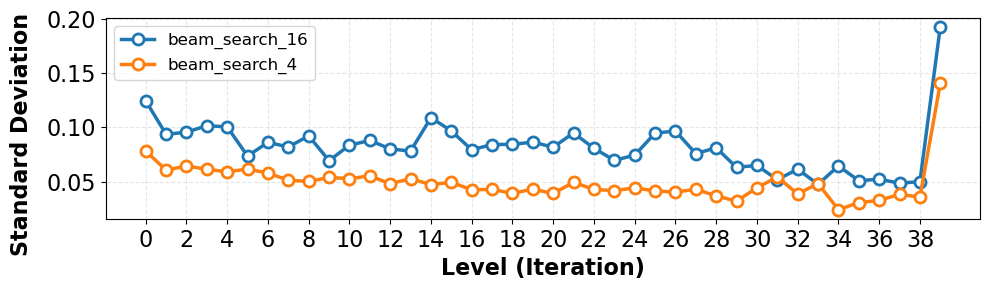

In [12]:
# Automatically find JSON files matching the pattern in the current directory
# You can also manually set json_files = ["file1.json", "file2.json"]

# Pattern to match the output from run_print_scores.sh
file_pattern = "*scores_stats*.json"
json_files = glob.glob(file_pattern)

# Sort files to ensure consistent legend order
json_files.sort()

print(f"Found files to plot: {json_files}")

if json_files:
    plot_scores(json_files)
else:
    print(f"No files matching '{file_pattern}' found in the current directory.")